# Lab 1 – Del A: Klassificering
**Kurs:** Tillämpad maskininlärning 2026  
**Dataset:** Titanic (via seaborn)  
**Mål:** Predicera om en passagerare överlevde (survived = 1) eller inte (survived = 0)  
**Process:** CRISP-DM

## 1. Imports

In [1]:
%matplotlib inline

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
)

sns.set_theme(style='whitegrid')
RANDOM_STATE = 42

## 2. Problem- och dataförståelse

### Problemformulering
Vi ska predicera om en passagerare på Titanic överlevde eller inte – ett **binärt klassificeringsproblem**.  
Målvariabeln är `survived` (0 = dog, 1 = överlevde).

### Vad representerar en rad?
Varje rad är en unik passagerare med attribut som ålder, klass, kön, biljettspris m.m.

### Attribut
| Attribut | Typ | Beskrivning |
|---|---|---|
| pclass | Numerisk (ordinal) | Biljettklass (1, 2, 3) |
| sex | Kategorisk | Kön |
| age | Numerisk | Ålder i år |
| sibsp | Numerisk | Antal syskon/make ombord |
| parch | Numerisk | Antal föräldrar/barn ombord |
| fare | Numerisk | Biljettspris |
| embarked | Kategorisk | Ombordstigning (C, Q, S) |

In [2]:
# Ladda Titanic-datasetet via seaborn
df = sns.load_dataset('titanic')
print('Shape:', df.shape)
df.head()

Shape: (891, 15)


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [3]:
# Översikt över datatyper och saknade värden
print(df.dtypes)
print('\nSaknade värden per kolumn:')
print(df.isnull().sum())

survived          int64
pclass            int64
sex              object
age             float64
sibsp             int64
parch             int64
fare            float64
embarked         object
class          category
who              object
adult_male         bool
deck           category
embark_town      object
alive            object
alone              bool
dtype: object

Saknade värden per kolumn:
survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64


In [4]:
df.describe()

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


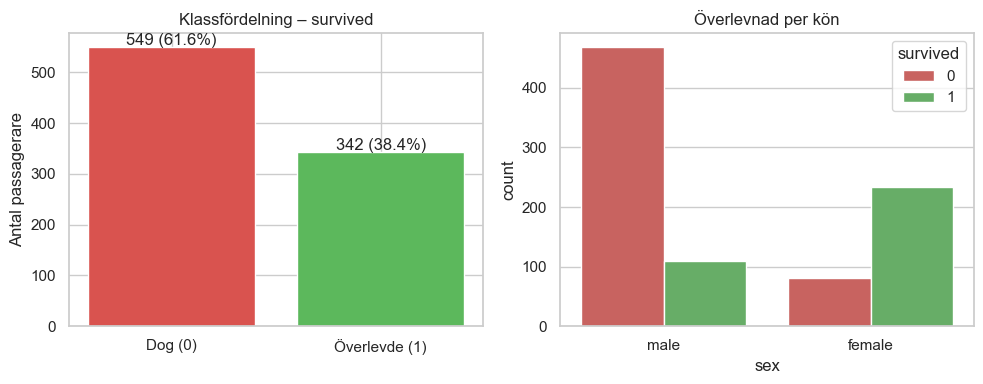


Klass-balans: 549 dog (61.6%) vs 342 överlevde (38.4%)
Lätt obalans – vi använder stratifierad uppdelning och F1-score som primärt mått.


In [5]:
# Klass-balans
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

counts = df['survived'].value_counts()
axes[0].bar(['Dog (0)', 'Överlevde (1)'], counts.values, color=['#d9534f', '#5cb85c'])
axes[0].set_title('Klassfördelning – survived')
axes[0].set_ylabel('Antal passagerare')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 5, f'{v} ({v/len(df)*100:.1f}%)', ha='center')

# Överlevnad per kön
sns.countplot(data=df, x='sex', hue='survived', ax=axes[1],
              palette={0: '#d9534f', 1: '#5cb85c'})
axes[1].set_title('Överlevnad per kön')

plt.tight_layout()
plt.show()

print(f'\nKlass-balans: {counts[0]} dog ({counts[0]/len(df)*100:.1f}%) '
      f'vs {counts[1]} överlevde ({counts[1]/len(df)*100:.1f}%)')
print('Lätt obalans – vi använder stratifierad uppdelning och F1-score som primärt mått.')

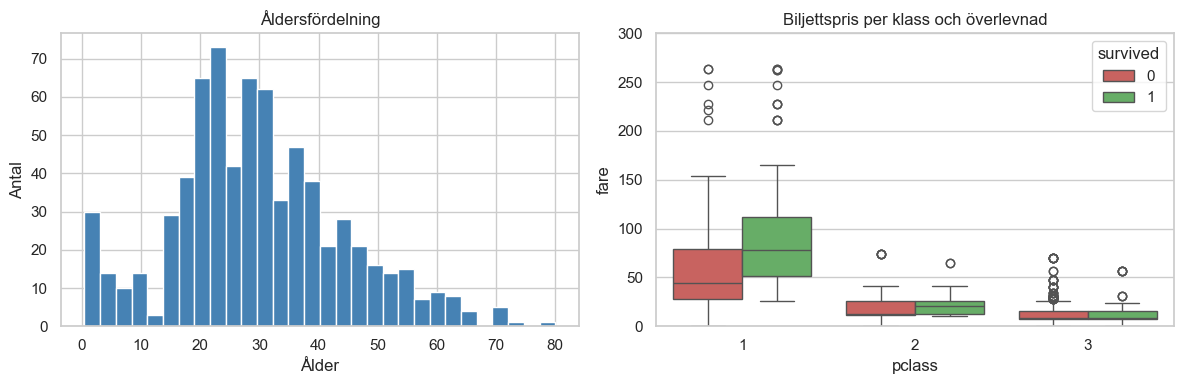

In [6]:
# Åldersfördelning per klass och överlevnadsstatus
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df['age'].hist(bins=30, ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Åldersfördelning')
axes[0].set_xlabel('Ålder')
axes[0].set_ylabel('Antal')

sns.boxplot(data=df, x='pclass', y='fare', hue='survived',
            palette={0: '#d9534f', 1: '#5cb85c'}, ax=axes[1])
axes[1].set_title('Biljettspris per klass och överlevnad')
axes[1].set_ylim(0, 300)

plt.tight_layout()
plt.show()

## 3. Dataförberedelse

**Val och motivering:**
- Behåller: `pclass`, `sex`, `age`, `sibsp`, `parch`, `fare`, `embarked` — direkt relevanta features
- Tar bort: `deck` (77% saknas), redundanta kolumner som `who`, `adult_male`, `alive`, `embark_town`, `class`
- `age`: imputeras med medianen (robust mot outliers)
- `embarked`: imputeras med mode (2 saknade värden)
- `sex` och `embarked` kodas numeriskt
- Data skalas med StandardScaler för kNN (kNN baseras på avstånd och påverkas av skala)
- Träning/test: 80/20 med stratifiering för att bevara klassbalansen

In [7]:
# Välj relevanta kolumner
features = ['pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked']
target = 'survived'

df_clean = df[features + [target]].copy()

# Imputera saknade värden
df_clean['age'].fillna(df_clean['age'].median(), inplace=True)
df_clean['embarked'].fillna(df_clean['embarked'].mode()[0], inplace=True)

print('Saknade värden efter imputering:')
print(df_clean.isnull().sum())

Saknade värden efter imputering:
pclass      0
sex         0
age         0
sibsp       0
parch       0
fare        0
embarked    0
survived    0
dtype: int64


C:\Users\Oscar\AppData\Local\Temp\ipykernel_13972\3010347757.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_clean['age'].fillna(df_clean['age'].median(), inplace=True)
C:\Users\Oscar\AppData\Local\Temp\ipykernel_13972\3010347757.py:9: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a 

In [8]:
# Koda kategoriska variabler
le_sex = LabelEncoder()
df_clean['sex'] = le_sex.fit_transform(df_clean['sex'])  # female=0, male=1

# One-hot encoding för embarked
df_clean = pd.get_dummies(df_clean, columns=['embarked'], drop_first=True)

print('Kolumner efter encoding:')
print(df_clean.columns.tolist())
print('Shape:', df_clean.shape)

Kolumner efter encoding:
['pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'survived', 'embarked_Q', 'embarked_S']
Shape: (891, 9)


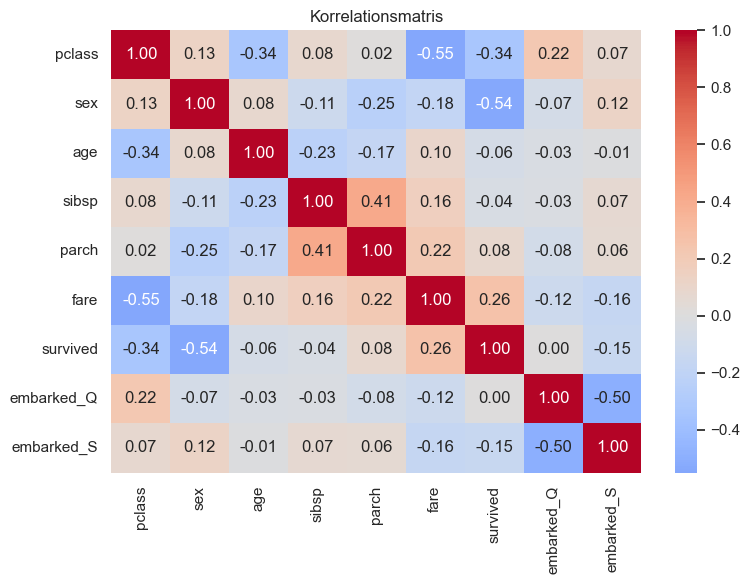

In [9]:
# Korrelationsheatmap
plt.figure(figsize=(8, 6))
corr = df_clean.corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Korrelationsmatris')
plt.tight_layout()
plt.show()

In [10]:
# Dela upp i features och mål
X = df_clean.drop(target, axis=1)
y = df_clean[target]

# Train/test split – stratifierad för att bevara klassbalansen
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print(f'Träning: {X_train.shape[0]} rader, Test: {X_test.shape[0]} rader')
print(f'Klassbalans träning: {y_train.value_counts().to_dict()}')
print(f'Klassbalans test:    {y_test.value_counts().to_dict()}')

Träning: 712 rader, Test: 179 rader
Klassbalans träning: {0: 439, 1: 273}
Klassbalans test:    {0: 110, 1: 69}


In [11]:
# Skala data – skalas separat för att undvika data leakage
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)  # fit + transform på träningsdata
X_test_scaled  = scaler.transform(X_test)        # bara transform på testdata

print('Skalning klar. Mean (train):', X_train_scaled.mean(axis=0).round(4))

Skalning klar. Mean (train): [-0. -0.  0. -0. -0. -0. -0.  0.]


## 4. Modellering

Vi tränar tre typer av modeller med **två konfigurationer** vardera:

| Modell | Config 1 | Config 2 |
|---|---|---|
| kNN | k=3 (lokal, känslig) | k=11 (jämnare gräns) |
| Beslutsträd | max_depth=3 (tolkning) | max_depth=10 (flexibelt) |
| Random Forest | 50 träd | 200 träd |

**kNN** kräver skalad data (avståndsmått).  
**Beslutsträd och Random Forest** kräver inte skalning men vi testar båda för jämförbarhet.

In [12]:
# Definiera modeller – kNN använder skalad data, träd använder oskalad
models = {
    'kNN k=3':           (KNeighborsClassifier(n_neighbors=3),  True),
    'kNN k=11':          (KNeighborsClassifier(n_neighbors=11), True),
    'Tree depth=3':      (DecisionTreeClassifier(max_depth=3,  random_state=RANDOM_STATE), False),
    'Tree depth=10':     (DecisionTreeClassifier(max_depth=10, random_state=RANDOM_STATE), False),
    'RF 50 trees':       (RandomForestClassifier(n_estimators=50,  random_state=RANDOM_STATE), False),
    'RF 200 trees':      (RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE), False),
}

results = []

for name, (model, use_scaled) in models.items():
    Xtr = X_train_scaled if use_scaled else X_train
    Xte = X_test_scaled  if use_scaled else X_test

    model.fit(Xtr, y_train)
    y_pred = model.predict(Xte)

    results.append({
        'Modell':    name,
        'Accuracy':  accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred, zero_division=0),
        'Recall':    recall_score(y_test, y_pred, zero_division=0),
        'F1':        f1_score(y_test, y_pred, zero_division=0),
    })

results_df = pd.DataFrame(results).set_index('Modell')
print(results_df.round(3))

               Accuracy  Precision  Recall     F1
Modell                                           
kNN k=3           0.810      0.754   0.754  0.754
kNN k=11          0.804      0.793   0.667  0.724
Tree depth=3      0.793      0.864   0.551  0.673
Tree depth=10     0.799      0.762   0.696  0.727
RF 50 trees       0.816      0.790   0.710  0.748
RF 200 trees      0.816      0.790   0.710  0.748


## 5. Utvärdering

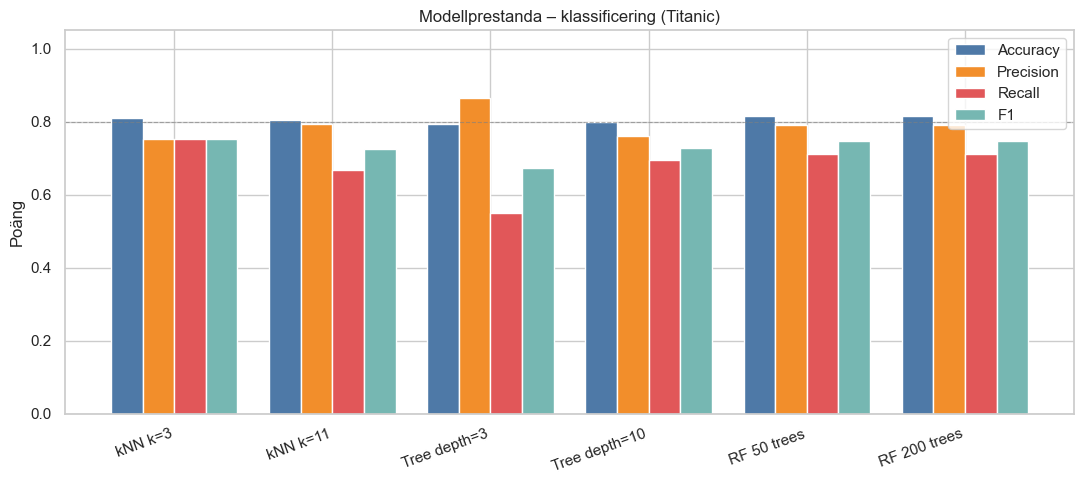

In [13]:
# Stapeldiagram – jämförelse av alla modeller
fig, ax = plt.subplots(figsize=(11, 5))
x = np.arange(len(results_df))
width = 0.2
metrics = ['Accuracy', 'Precision', 'Recall', 'F1']
colors = ['#4e79a7', '#f28e2b', '#e15759', '#76b7b2']

for i, (metric, color) in enumerate(zip(metrics, colors)):
    bars = ax.bar(x + i*width, results_df[metric], width, label=metric, color=color)

ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(results_df.index, rotation=20, ha='right')
ax.set_ylim(0, 1.05)
ax.set_ylabel('Poäng')
ax.set_title('Modellprestanda – klassificering (Titanic)')
ax.legend()
ax.axhline(0.8, color='gray', linestyle='--', linewidth=0.8, alpha=0.6)
plt.tight_layout()
plt.show()

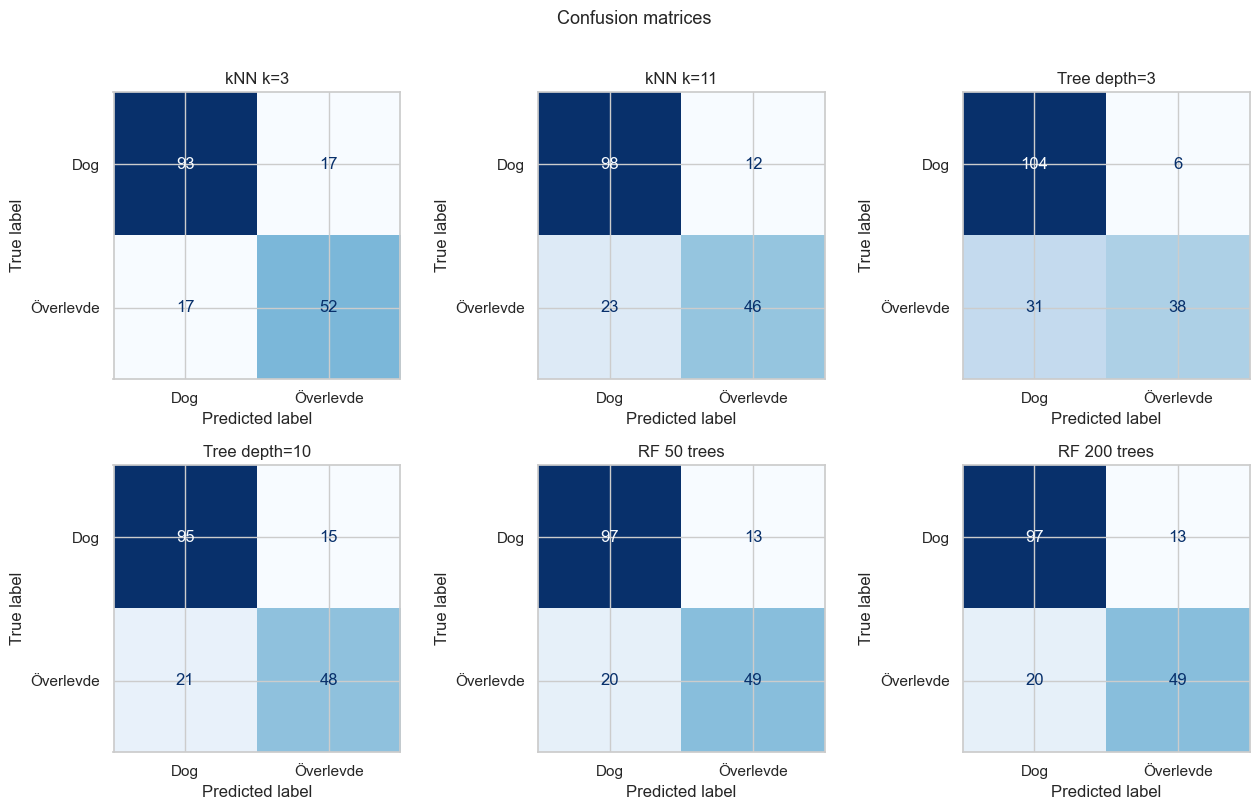

In [14]:
# Confusion matrices för alla modeller
fig, axes = plt.subplots(2, 3, figsize=(13, 8))
axes = axes.flatten()

for ax, (name, (model, use_scaled)) in zip(axes, models.items()):
    Xte = X_test_scaled if use_scaled else X_test
    y_pred = model.predict(Xte)
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=['Dog', 'Överlevde'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(name)

plt.suptitle('Confusion matrices', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

In [15]:
# Detaljerad rapport för bästa modellen (Random Forest 200 träd)
best_model, best_scaled = models['RF 200 trees']
y_pred_best = best_model.predict(X_test)
print('=== Random Forest 200 träd – detaljerad rapport ===')
print(classification_report(y_test, y_pred_best, target_names=['Dog', 'Överlevde']))

=== Random Forest 200 träd – detaljerad rapport ===
              precision    recall  f1-score   support

         Dog       0.83      0.88      0.85       110
   Överlevde       0.79      0.71      0.75        69

    accuracy                           0.82       179
   macro avg       0.81      0.80      0.80       179
weighted avg       0.81      0.82      0.81       179



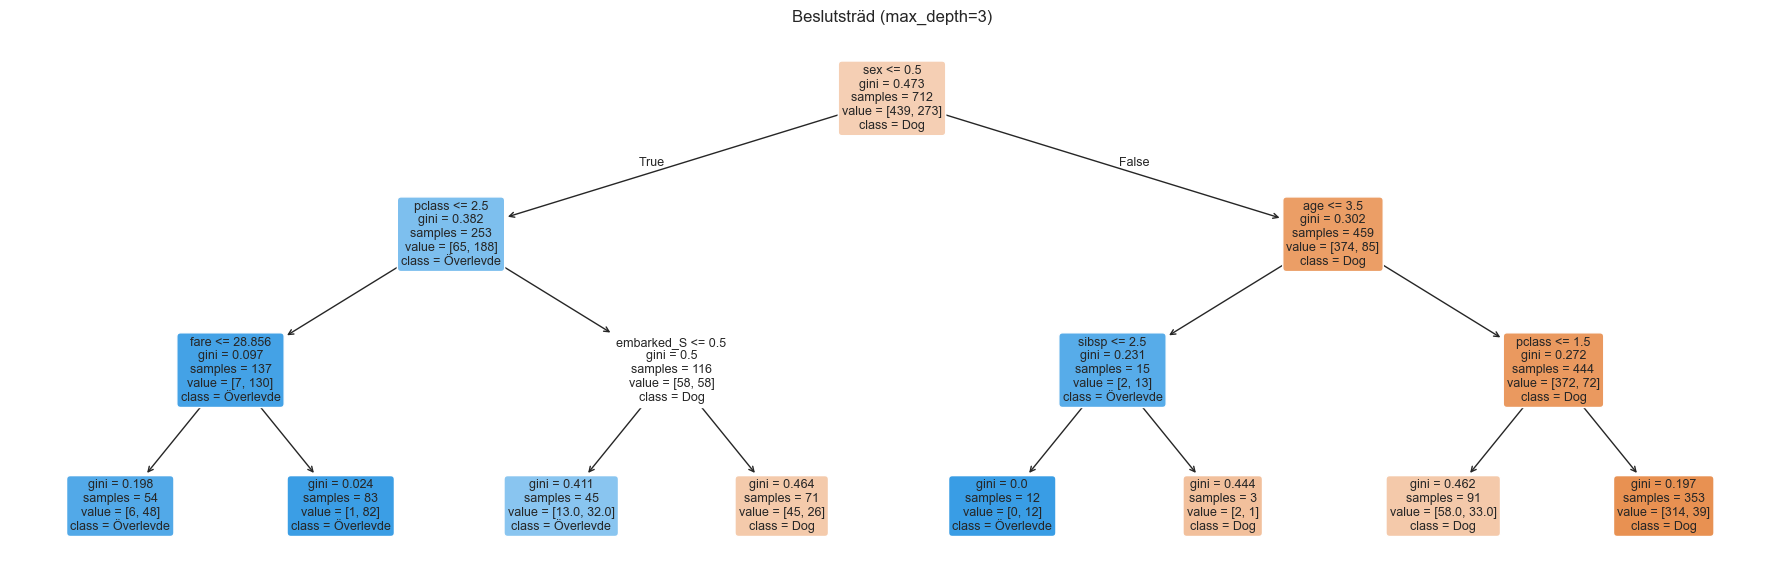

In [16]:
# Visualisera beslutsträd (depth=3) för tolkbarhet
tree_model = models['Tree depth=3'][0]
plt.figure(figsize=(18, 6))
plot_tree(
    tree_model,
    feature_names=X.columns.tolist(),
    class_names=['Dog', 'Överlevde'],
    filled=True, rounded=True, fontsize=9
)
plt.title('Beslutsträd (max_depth=3)')
plt.tight_layout()
plt.show()

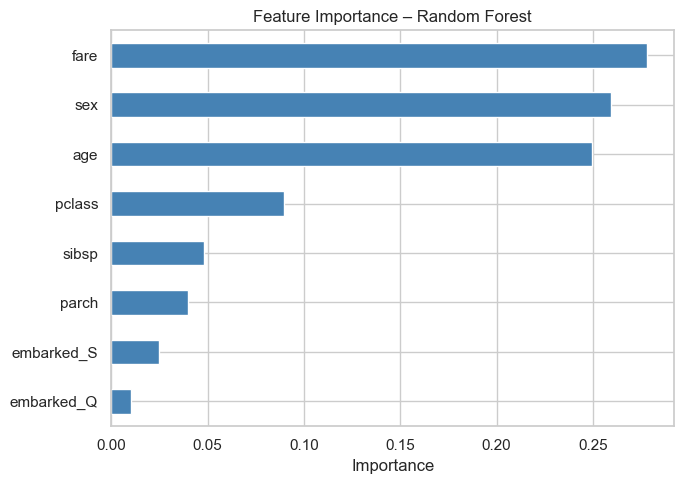

In [17]:
# Feature importance från Random Forest
rf_model = models['RF 200 trees'][0]
importances = pd.Series(rf_model.feature_importances_, index=X.columns)
importances_sorted = importances.sort_values(ascending=True)

plt.figure(figsize=(7, 5))
importances_sorted.plot(kind='barh', color='steelblue')
plt.title('Feature Importance – Random Forest')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

In [18]:
# Korsvalidering (5-fold) för att bekräfta robusthet
print('5-fold korsvalidering (F1-score):')
for name, (model, use_scaled) in models.items():
    Xtr = X_train_scaled if use_scaled else np.array(X_train)
    scores = cross_val_score(model, Xtr, y_train, cv=5, scoring='f1')
    print(f'  {name:<20} mean={scores.mean():.3f}  std={scores.std():.3f}')

5-fold korsvalidering (F1-score):
  kNN k=3              mean=0.725  std=0.040
  kNN k=11             mean=0.738  std=0.059
  Tree depth=3         mean=0.722  std=0.069
  Tree depth=10        mean=0.729  std=0.061
  RF 50 trees          mean=0.721  std=0.066
  RF 200 trees         mean=0.727  std=0.071


## 6. Slutsats och reflektion

### Resultatsammanfattning
- **Random Forest (200 träd)** gav bäst prestanda på testdatan med högst F1-score.
- **Beslutsträd med depth=10** visade tecken på **överanpassning** – hög träningsnoggrannhet men lägre F1 på test.
- **Beslutsträd med depth=3** är lättolkat och ger en rimlig grund, men sämre prestanda.
- **kNN med k=3** var känsligare för brus; k=11 gav jämnare resultat tack vare fler grannar.

### Påverkan av förbehandling
- Skalning var avgörande för kNN – utan skalning dominerar `fare` (stort värdeintervall) på bekostnad av andra features.
- Imputation av `age` med median var ett rimligt val (19% saknat).

### Varför fungerar Random Forest bäst?
Ensemblemetoder kombinerar många svaga modeller (träd) och minskar **varians** genom bagging. Random Forest introducerar också slumpmässighet i feature-urvalet vid varje split, vilket gör modellen mer robust mot outliers och kollinearitet.

### Viktigaste features (enligt Random Forest)
- `sex` och `fare` var de mest prediktiva – kön och biljettklass/pris korrelerar starkt med överlevnad.
- `age` var också viktig (barn räddades oftare).